In [8]:
# import data

import pandas as pd

df = pd.read_csv("../data/thyroid_cancer_risk_data.csv")

df.head()

,Patient_ID,Age,Gender,Country,Ethnicity,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,TSH_Level,T3_Level,T4_Level,Nodule_Size,Thyroid_Cancer_Risk,Diagnosis
0,1,66,Male,Russia,Caucasian,No,Yes,No,No,No,No,9.37,1.67,6.16,1.08,Low,Benign
1,2,29,Male,Germany,Hispanic,No,Yes,No,No,No,No,1.83,1.73,10.54,4.05,Low,Benign
2,3,86,Male,Nigeria,Caucasian,No,No,No,No,No,No,6.26,2.59,10.57,4.61,Low,Benign
3,4,75,Female,India,Asian,No,No,No,No,No,No,4.10,2.62,11.04,2.46,Medium,Benign
4,5,35,Female,Germany,African,Yes,Yes,No,No,No,No,9.10,2.11,10.71,2.11,High,Benign


In [9]:
print("number of unique patients in dataset:", df["Patient_ID"].nunique())

print(df.describe(include = "all"))

# change Patient_ID column to string because Patient_ID is a categorical variable
df["Patient_ID"] = df["Patient_ID"].astype(str)

number of unique patients in dataset: 212691
          Patient_ID            Age  Gender Country  Ethnicity Family_History  \
count   212691.00000  212691.000000  212691  212691     212691         212691   
unique           NaN            NaN       2      10          5              2   
top              NaN            NaN  Female   India  Caucasian             No   
freq             NaN            NaN  127527   42496      63669         148866   
mean    106346.00000      51.918497     NaN     NaN        NaN            NaN   
std      61398.74739      21.632815     NaN     NaN        NaN            NaN   
min          1.00000      15.000000     NaN     NaN        NaN            NaN   
25%      53173.50000      33.000000     NaN     NaN        NaN            NaN   
50%     106346.00000      52.000000     NaN     NaN        NaN            NaN   
75%     159518.50000      71.000000     NaN     NaN        NaN            NaN   
max     212691.00000      89.000000     NaN     NaN        NaN  

In [10]:
# Get Basic Info

shape = df.shape
print(f"shape of dataframe: {shape}")

colnames = df.columns
print(f"Column Names of dataframe: {colnames}")

data_types = df.dtypes
print(f"Data Types of dataframe: {data_types}")

missing_values = df.isnull().sum()
print(f"Missing values of dataframe: {missing_values}")

shape of dataframe: (212691, 17)
Column Names of dataframe: Index(['Patient_ID', 'Age', 'Gender', 'Country', 'Ethnicity', 'Family_History',
       'Radiation_Exposure', 'Iodine_Deficiency', 'Smoking', 'Obesity',
       'Diabetes', 'TSH_Level', 'T3_Level', 'T4_Level', 'Nodule_Size',
       'Thyroid_Cancer_Risk', 'Diagnosis'],
      dtype='object')
Data Types of dataframe: Patient_ID              object
Age                      int64
Gender                  object
Country                 object
Ethnicity               object
Family_History          object
Radiation_Exposure      object
Iodine_Deficiency       object
Smoking                 object
Obesity                 object
Diabetes                object
TSH_Level              float64
T3_Level               float64
T4_Level               float64
Nodule_Size            float64
Thyroid_Cancer_Risk     object
Diagnosis               object
dtype: object
Missing values of dataframe: Patient_ID             0
Age                    0
Gender

In [11]:
# now I compile 'output/data_info.txt'

with open('../output/data_info.txt', 'w') as f:
    f.write(f'Dataset Shape: {shape[0]} rows × {shape[1]} columns\n')
    f.write(f'Column Names:\n')
    for col in colnames:
        f.write(f' - {col}\n')
    f.write(f'\nData Types:\n')
    for col, dtype in data_types.items():
        f.write(f' - {col}: {dtype}\n')
    f.write(f'\nMissing Values per Column:\n')
    for col, missing in missing_values.items():
        f.write(f' - {col}: {missing}\n')

In [12]:
# I compile 'output/exploration.csv'

numeric_df = df.select_dtypes(include='number')
numeric_df_colnames = numeric_df.columns

missing_values_numeric = numeric_df.isna().sum()

# find outliers per column

outliers_dict= {}
for col in numeric_df_colnames:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    outliers_dict[col] = len(outliers)

print(f"dictionary of outlier values in dataframe: {outliers_dict}")

data = {
    'column_name': numeric_df_colnames,
    'mean': [float(numeric_df[col].mean()) for col in numeric_df_colnames],
    'std': [float(numeric_df[col].std()) for col in numeric_df_colnames],
    'min': [float(numeric_df[col].min()) for col in numeric_df_colnames],
    'max': [float(numeric_df[col].max()) for col in numeric_df_colnames],
    'missing_count': [int(missing_values_numeric[col]) for col in numeric_df_colnames],
    'number_of_outliers': [outliers_dict[col] for col in numeric_df_colnames]}

print(data)

csv_df = pd.DataFrame(data)
csv_df.to_csv('../output/exploration.csv', index=False)

print(csv_df)

dictionary of outlier values in dataframe: {'Age': 0, 'TSH_Level': 0, 'T3_Level': 0, 'T4_Level': 0, 'Nodule_Size': 0}
{'column_name': Index(['Age', 'TSH_Level', 'T3_Level', 'T4_Level', 'Nodule_Size'], dtype='object'), 'mean': [51.918496786417855, 5.045102002435458, 2.0017266362939665, 8.246203976660977, 2.503403246963906], 'std': [21.632814529081358, 2.8602640689761456, 0.8662480194769662, 2.16418847600702, 1.44463073072601], 'min': [15.0, 0.1, 0.5, 4.5, 0.0], 'max': [89.0, 10.0, 3.5, 12.0, 5.0], 'missing_count': [0, 0, 0, 0, 0], 'number_of_outliers': [0, 0, 0, 0, 0]}
   column_name       mean        std   min   max  missing_count  \
0          Age  51.918497  21.632815  15.0  89.0              0   
1    TSH_Level   5.045102   2.860264   0.1  10.0              0   
2     T3_Level   2.001727   0.866248   0.5   3.5              0   
3     T4_Level   8.246204   2.164188   4.5  12.0              0   
4  Nodule_Size   2.503403   1.444631   0.0   5.0              0   

   number_of_outliers 

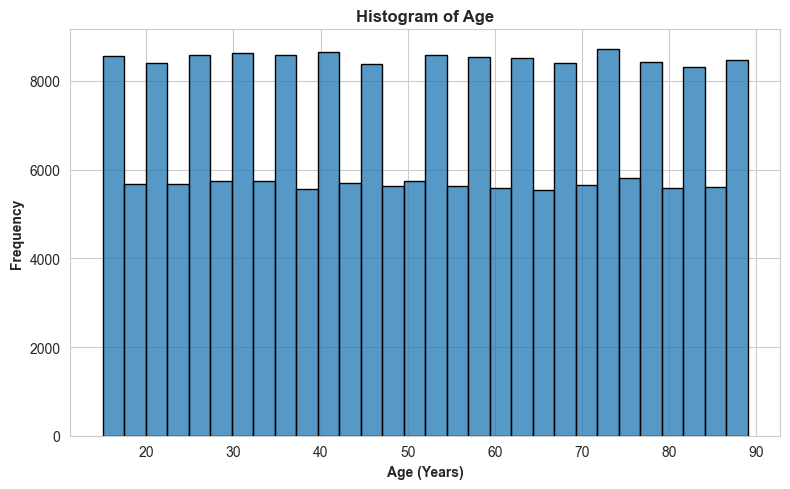

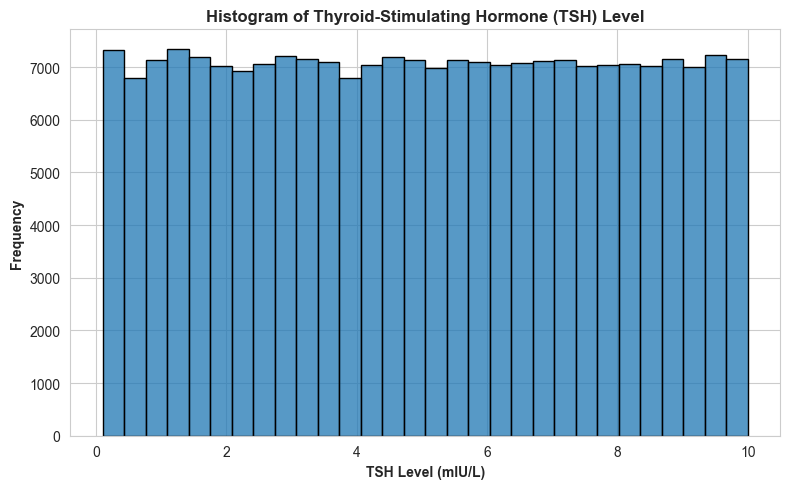

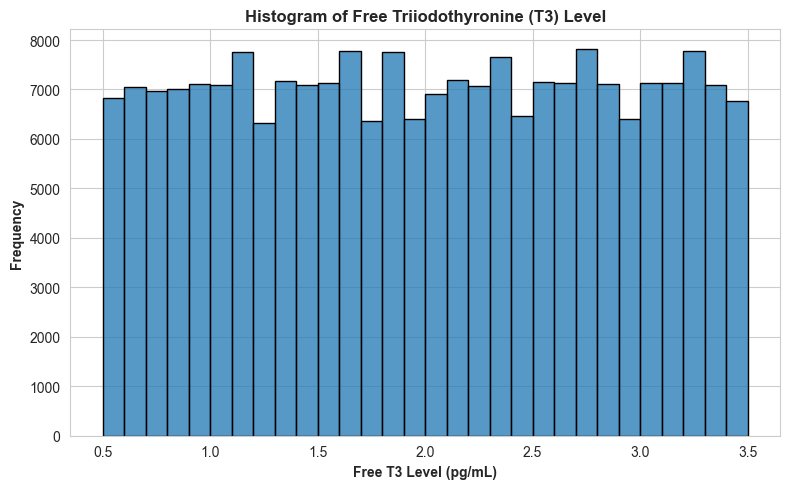

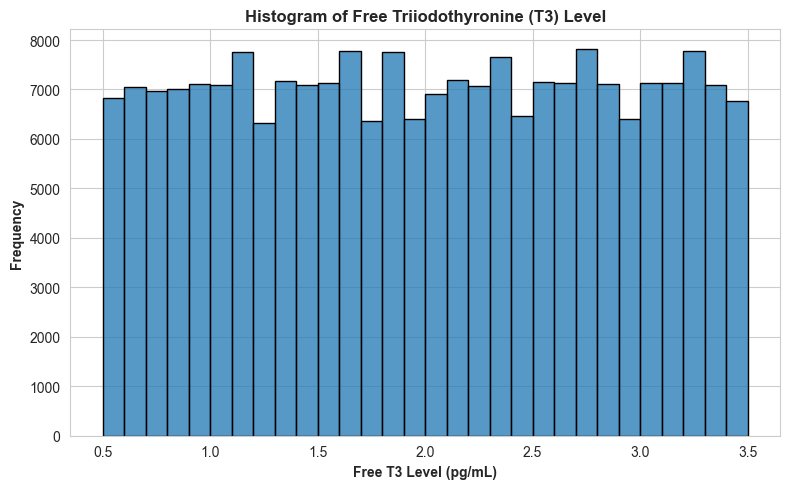

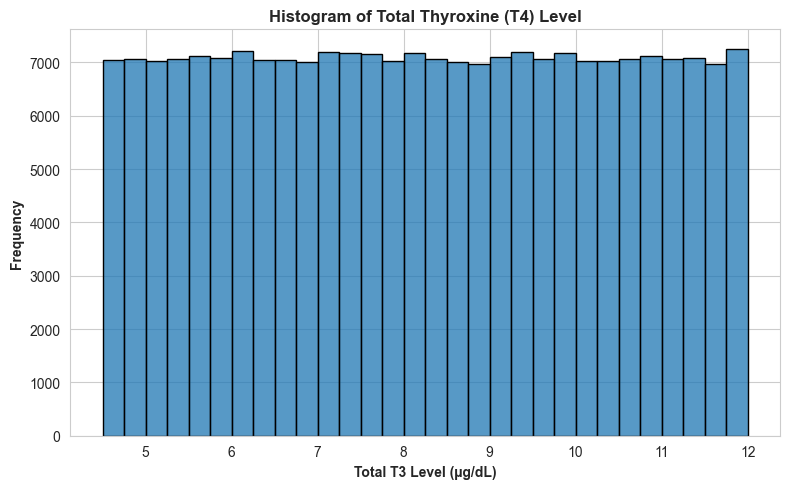

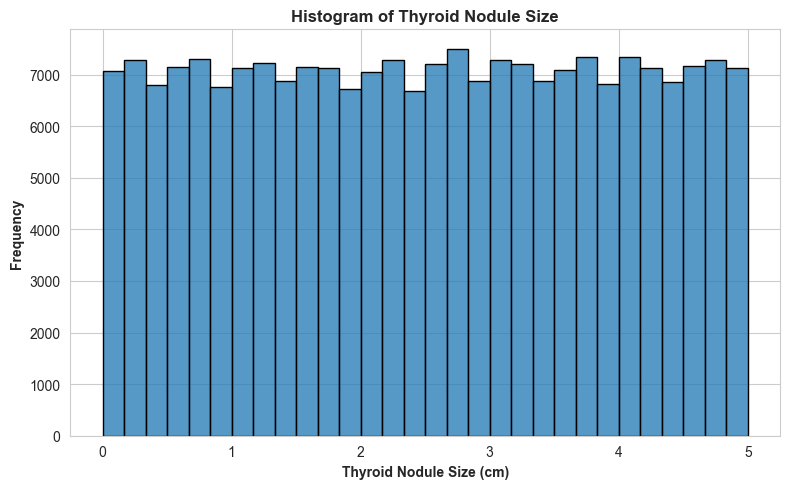

In [ ]:
# generate some initial visualizations

# histograms of numeric variables in dataframe

import seaborn as sns
import matplotlib.pyplot as plt

# Histogram of Age
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")
sns.histplot(df['Age'], bins=30, edgecolor = 'black')  
plt.title('Histogram of Age', fontweight='bold')
plt.xlabel("Age (Years)", fontweight='bold')
plt.ylabel('Frequency', fontweight='bold')
plt.tight_layout()
plt.savefig("../output/age_histogram.png", dpi=300)
plt.show()

# Histogram of TSH_Level
plt.figure(figsize=(8, 5))
sns.histplot(df['TSH_Level'], bins=30, edgecolor = 'black') 
plt.title('Histogram of Thyroid-Stimulating Hormone (TSH) Level', fontweight='bold')
plt.xlabel("TSH Level (mIU/L)", fontweight='bold')
plt.ylabel('Frequency', fontweight='bold')
plt.tight_layout()
plt.savefig("../output/tsh_histogram.png", dpi=300)
plt.show()

# Histogram of T3_Level
plt.figure(figsize=(8, 5))
sns.histplot(df['T3_Level'], bins=30, edgecolor = 'black') 
plt.title('Histogram of Free Triiodothyronine (T3) Level', fontweight='bold')
plt.xlabel("Free T3 Level (pg/mL)", fontweight='bold')
plt.ylabel('Frequency', fontweight='bold')
plt.tight_layout()
plt.savefig("../output/t3_histogram.png", dpi=300)
plt.show()

# Histogram of T4_Level
plt.figure(figsize=(8, 5))
sns.histplot(df['T4_Level'], bins=30, edgecolor = 'black')  
plt.title('Histogram of Total Thyroxine (T4) Level', fontweight='bold')
plt.xlabel("Total T3 Level (µg/dL)", fontweight='bold')
plt.ylabel('Frequency', fontweight='bold')
plt.tight_layout()
plt.savefig("../output/t4_histogram.png", dpi=300)
plt.show()

# Histogram of Nodule_Size
plt.figure(figsize=(8, 5))
sns.histplot(df['Nodule_Size'], bins=30, edgecolor = 'black')  
plt.title('Histogram of Thyroid Nodule Size', fontweight='bold')
plt.xlabel("Thyroid Nodule Size (cm)", fontweight='bold')
plt.ylabel('Frequency', fontweight='bold')
plt.tight_layout()
plt.savefig("../output/nodule_size_histogram.png", dpi=300)
plt.show()

/var/folders/fz/lz55mbm51216f101cqgbdzlh0000gn/T/ipykernel_7757/2503190713.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df['Gender'], palette='colorblind', alpha = 0.8, edgecolor = 'black')
/Users/audreysu/p3/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/audreysu/p3/lib/python3.10/site-packages/seaborn/categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or expli

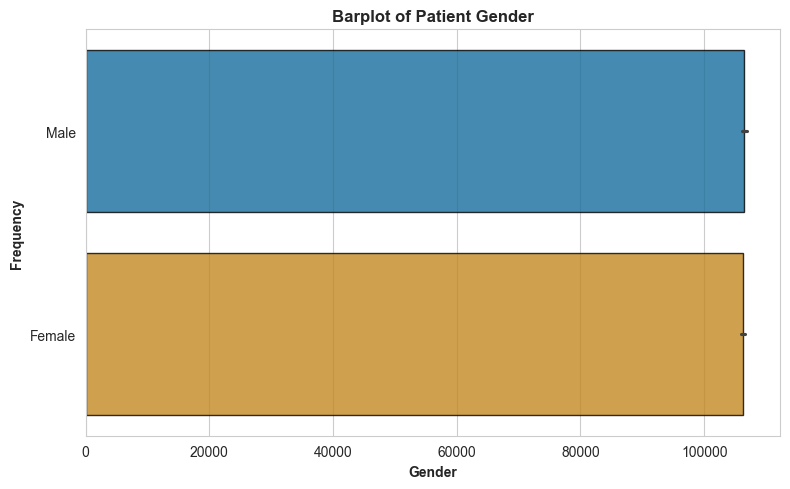

/var/folders/fz/lz55mbm51216f101cqgbdzlh0000gn/T/ipykernel_7757/2503190713.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df['Country'], palette='colorblind', alpha = 0.8, edgecolor = 'black')
/Users/audreysu/p3/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/audreysu/p3/lib/python3.10/site-packages/seaborn/categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or exp

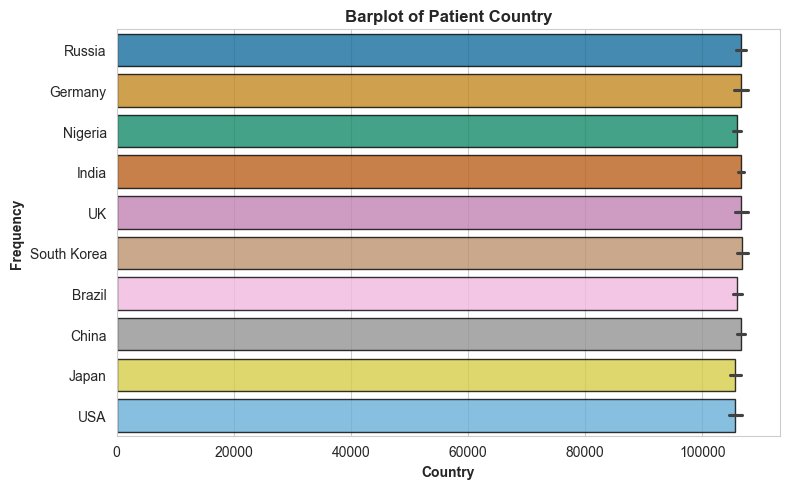

/var/folders/fz/lz55mbm51216f101cqgbdzlh0000gn/T/ipykernel_7757/2503190713.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df['Ethnicity'], palette='colorblind', alpha = 0.8, edgecolor = 'black')
/Users/audreysu/p3/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/audreysu/p3/lib/python3.10/site-packages/seaborn/categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or e

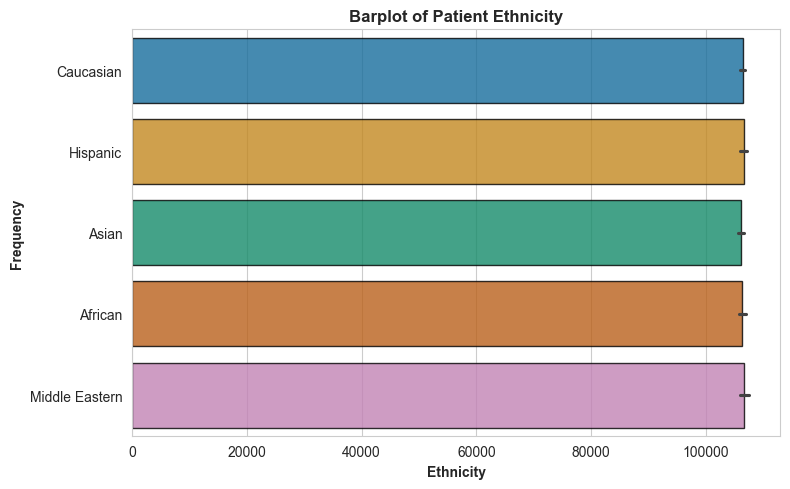

/var/folders/fz/lz55mbm51216f101cqgbdzlh0000gn/T/ipykernel_7757/2503190713.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df['Family_History'], palette='colorblind', alpha = 0.8, edgecolor = 'black')
/Users/audreysu/p3/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/audreysu/p3/lib/python3.10/site-packages/seaborn/categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings

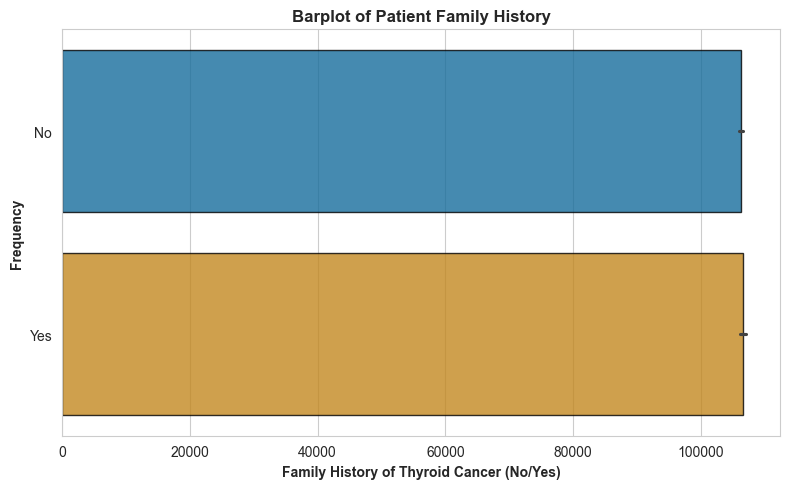

/var/folders/fz/lz55mbm51216f101cqgbdzlh0000gn/T/ipykernel_7757/2503190713.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df['Radiation_Exposure'], palette='colorblind', alpha = 0.8, edgecolor = 'black')
/Users/audreysu/p3/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/audreysu/p3/lib/python3.10/site-packages/seaborn/categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the group

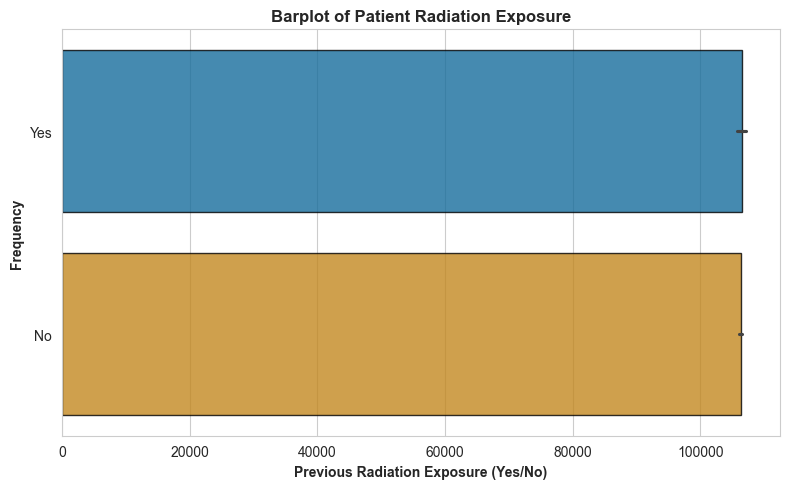

/var/folders/fz/lz55mbm51216f101cqgbdzlh0000gn/T/ipykernel_7757/2503190713.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df['Iodine_Deficiency'], palette='colorblind', alpha = 0.8, edgecolor = 'black')
/Users/audreysu/p3/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/audreysu/p3/lib/python3.10/site-packages/seaborn/categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupi

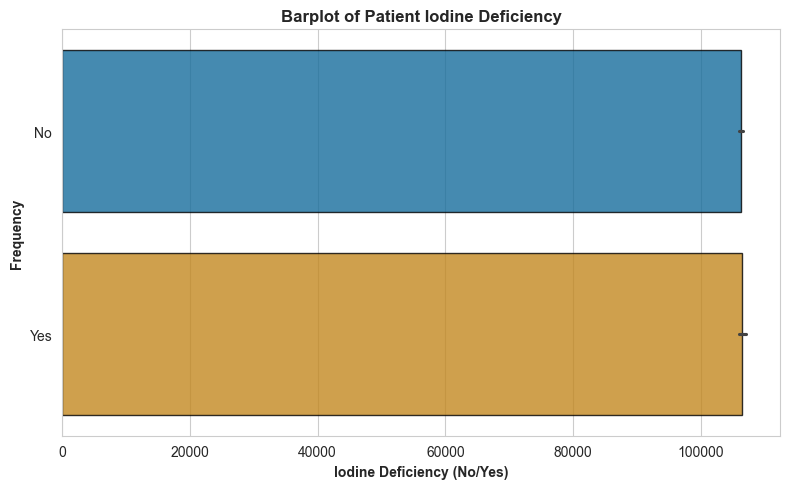

/var/folders/fz/lz55mbm51216f101cqgbdzlh0000gn/T/ipykernel_7757/2503190713.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df['Smoking'], palette='colorblind', alpha = 0.8, edgecolor = 'black')
/Users/audreysu/p3/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/audreysu/p3/lib/python3.10/site-packages/seaborn/categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or exp

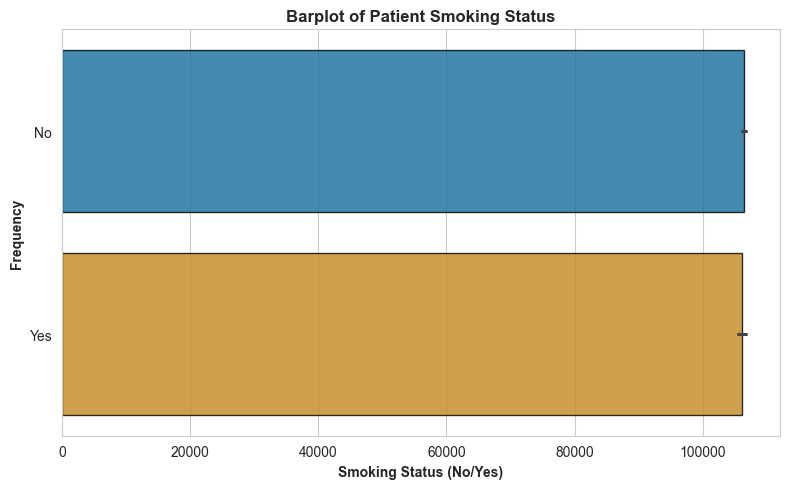

/var/folders/fz/lz55mbm51216f101cqgbdzlh0000gn/T/ipykernel_7757/2503190713.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df['Obesity'], palette='colorblind', alpha = 0.8, edgecolor = 'black')
/Users/audreysu/p3/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/audreysu/p3/lib/python3.10/site-packages/seaborn/categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or exp

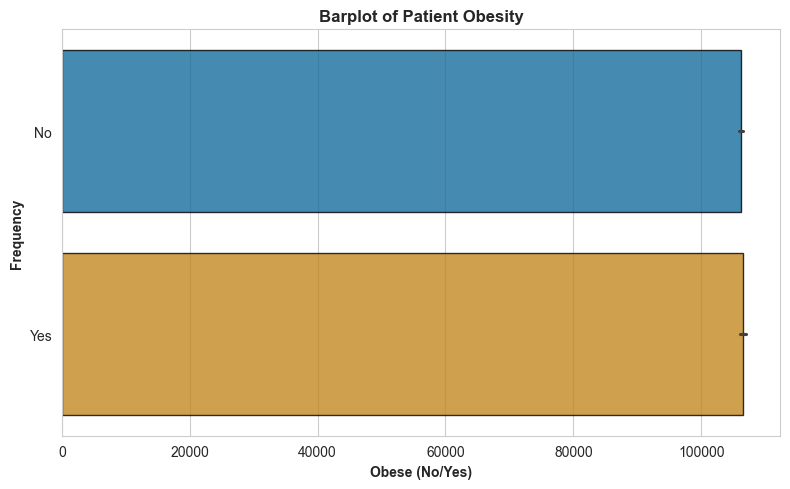

/var/folders/fz/lz55mbm51216f101cqgbdzlh0000gn/T/ipykernel_7757/2503190713.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df['Diabetes'], palette='colorblind', alpha = 0.8, edgecolor = 'black')
/Users/audreysu/p3/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/audreysu/p3/lib/python3.10/site-packages/seaborn/categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or ex

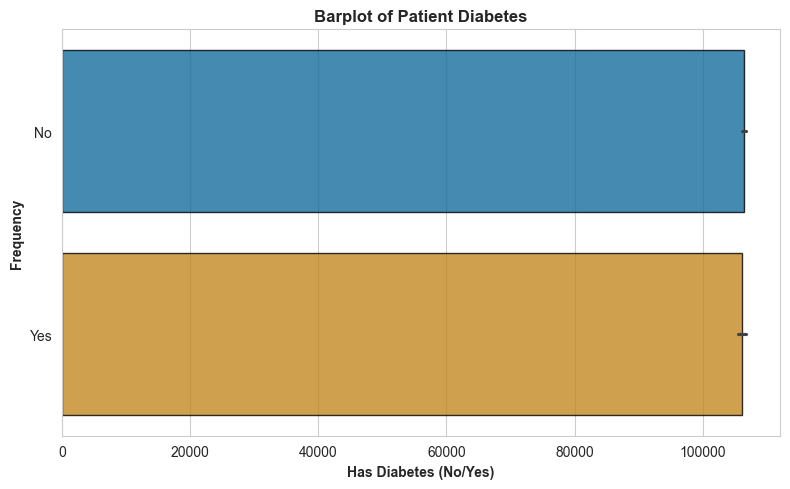

/var/folders/fz/lz55mbm51216f101cqgbdzlh0000gn/T/ipykernel_7757/2503190713.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df['Thyroid_Cancer_Risk'], palette='colorblind', alpha = 0.8, edgecolor = 'black')
/Users/audreysu/p3/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/audreysu/p3/lib/python3.10/site-packages/seaborn/categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the grou

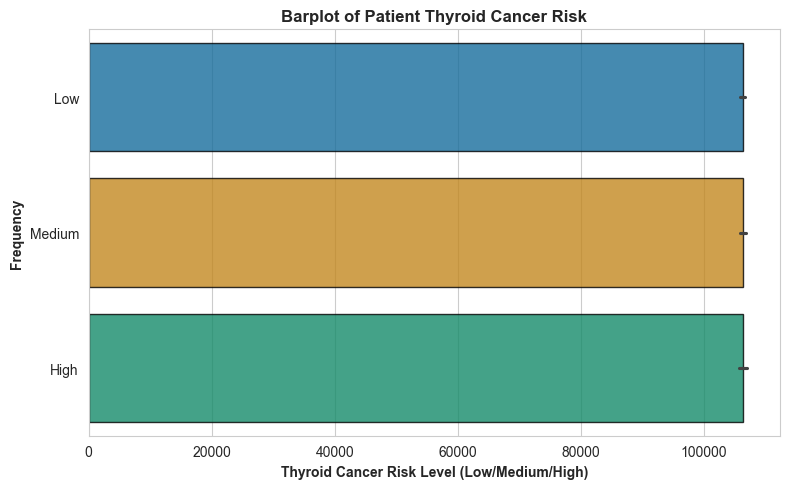

/var/folders/fz/lz55mbm51216f101cqgbdzlh0000gn/T/ipykernel_7757/2503190713.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df['Diagnosis'], palette='colorblind', alpha = 0.8, edgecolor = 'black')
/Users/audreysu/p3/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/audreysu/p3/lib/python3.10/site-packages/seaborn/categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or 

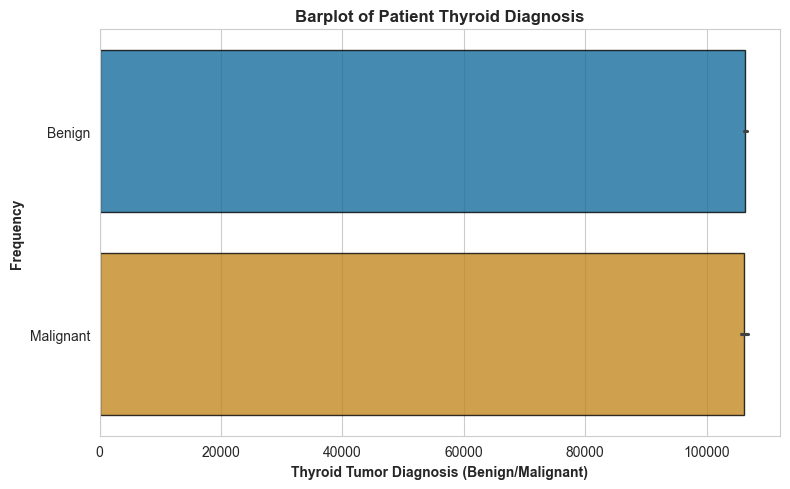

In [14]:
# barplots of categorical variables in dataframe

# Barplot of Gender
plt.figure(figsize=(8, 5))
sns.barplot(df['Gender'], palette='colorblind', alpha = 0.8, edgecolor = 'black')
plt.title("Barplot of Patient Gender", fontweight = "bold")
plt.xlabel("Gender", fontweight = "bold")
plt.ylabel("Frequency", fontweight = "bold")
plt.tight_layout()
plt.savefig("../output/gender.png", dpi=300)
plt.show()

# Barplot of Country
plt.figure(figsize=(8, 5))
sns.barplot(df['Country'], palette='colorblind', alpha = 0.8, edgecolor = 'black')
plt.title("Barplot of Patient Country", fontweight = "bold")
plt.xlabel("Country", fontweight = "bold")
plt.ylabel("Frequency", fontweight = "bold")
plt.tight_layout()
plt.savefig("../output/country.png", dpi=300)
plt.show()

# Barplot of Ethnicity
plt.figure(figsize=(8, 5))
sns.barplot(df['Ethnicity'], palette='colorblind', alpha = 0.8, edgecolor = 'black')
plt.title("Barplot of Patient Ethnicity", fontweight = "bold")
plt.xlabel("Ethnicity", fontweight = "bold")
plt.ylabel("Frequency", fontweight = "bold")
plt.tight_layout()
plt.savefig("../output/ethnicity.png", dpi=300)
plt.show()

# Barplot of Family_History
plt.figure(figsize=(8, 5))
sns.barplot(df['Family_History'], palette='colorblind', alpha = 0.8, edgecolor = 'black')
plt.title("Barplot of Patient Family History", fontweight = "bold")
plt.xlabel("Family History of Thyroid Cancer (No/Yes)", fontweight = "bold")
plt.ylabel("Frequency", fontweight = "bold")
plt.tight_layout()
plt.savefig("../output/family_history.png", dpi=300)
plt.show()

# Barplot of Radiation_Exposure
plt.figure(figsize=(8, 5))
sns.barplot(df['Radiation_Exposure'], palette='colorblind', alpha = 0.8, edgecolor = 'black')
plt.title("Barplot of Patient Radiation Exposure", fontweight = "bold")
plt.xlabel("Previous Radiation Exposure (Yes/No)", fontweight = "bold")
plt.ylabel("Frequency", fontweight = "bold")
plt.tight_layout()
plt.savefig("../output/radiation_exposure.png", dpi=300)
plt.show()

# Barplot of Iodine_Deficiency
plt.figure(figsize=(8, 5))
sns.barplot(df['Iodine_Deficiency'], palette='colorblind', alpha = 0.8, edgecolor = 'black')
plt.title("Barplot of Patient Iodine Deficiency", fontweight = "bold")
plt.xlabel("Iodine Deficiency (No/Yes)", fontweight = "bold")
plt.ylabel("Frequency", fontweight = "bold")
plt.tight_layout()
plt.savefig("../output/iodine_deficiency.png", dpi=300)
plt.show()

# Barplot of Smoking
plt.figure(figsize=(8, 5))
sns.barplot(df['Smoking'], palette='colorblind', alpha = 0.8, edgecolor = 'black')
plt.title("Barplot of Patient Smoking Status", fontweight = "bold")
plt.xlabel("Smoking Status (No/Yes)", fontweight = "bold")
plt.ylabel("Frequency", fontweight = "bold")
plt.tight_layout()
plt.savefig("../output/smoking.png", dpi=300)
plt.show()

# Barplot of Obesity
plt.figure(figsize=(8, 5))
sns.barplot(df['Obesity'], palette='colorblind', alpha = 0.8, edgecolor = 'black')
plt.title("Barplot of Patient Obesity", fontweight = "bold")
plt.xlabel("Obese (No/Yes)", fontweight = "bold")
plt.ylabel("Frequency", fontweight = "bold")
plt.tight_layout()
plt.savefig("../output/obesity.png", dpi=300)
plt.show()

# Barplot of Diabetes
plt.figure(figsize=(8, 5))
sns.barplot(df['Diabetes'], palette='colorblind', alpha = 0.8, edgecolor = 'black')
plt.title("Barplot of Patient Diabetes", fontweight = "bold")
plt.xlabel("Has Diabetes (No/Yes)", fontweight = "bold")
plt.ylabel("Frequency", fontweight = "bold")
plt.tight_layout()
plt.savefig("../output/diabetes.png", dpi=300)
plt.show()

# Barplot of Thyroid_Cancer_Risk
plt.figure(figsize=(8, 5))
sns.barplot(df['Thyroid_Cancer_Risk'], palette='colorblind', alpha = 0.8, edgecolor = 'black')
plt.title("Barplot of Patient Thyroid Cancer Risk", fontweight = "bold")
plt.xlabel("Thyroid Cancer Risk Level (Low/Medium/High)", fontweight = "bold")
plt.ylabel("Frequency", fontweight = "bold")
plt.tight_layout()
plt.savefig("../output/thyroid_cancer_risk.png", dpi=300)
plt.show()

# Barplot of Diagnosis
plt.figure(figsize=(8, 5))
sns.barplot(df['Diagnosis'], palette='colorblind', alpha = 0.8, edgecolor = 'black')
plt.title("Barplot of Patient Thyroid Diagnosis", fontweight = "bold")
plt.xlabel("Thyroid Tumor Diagnosis (Benign/Malignant)", fontweight = "bold")
plt.ylabel("Frequency", fontweight = "bold")
plt.tight_layout()
plt.savefig("../output/diagnosis.png", dpi=300)
plt.show()

(5, 5)


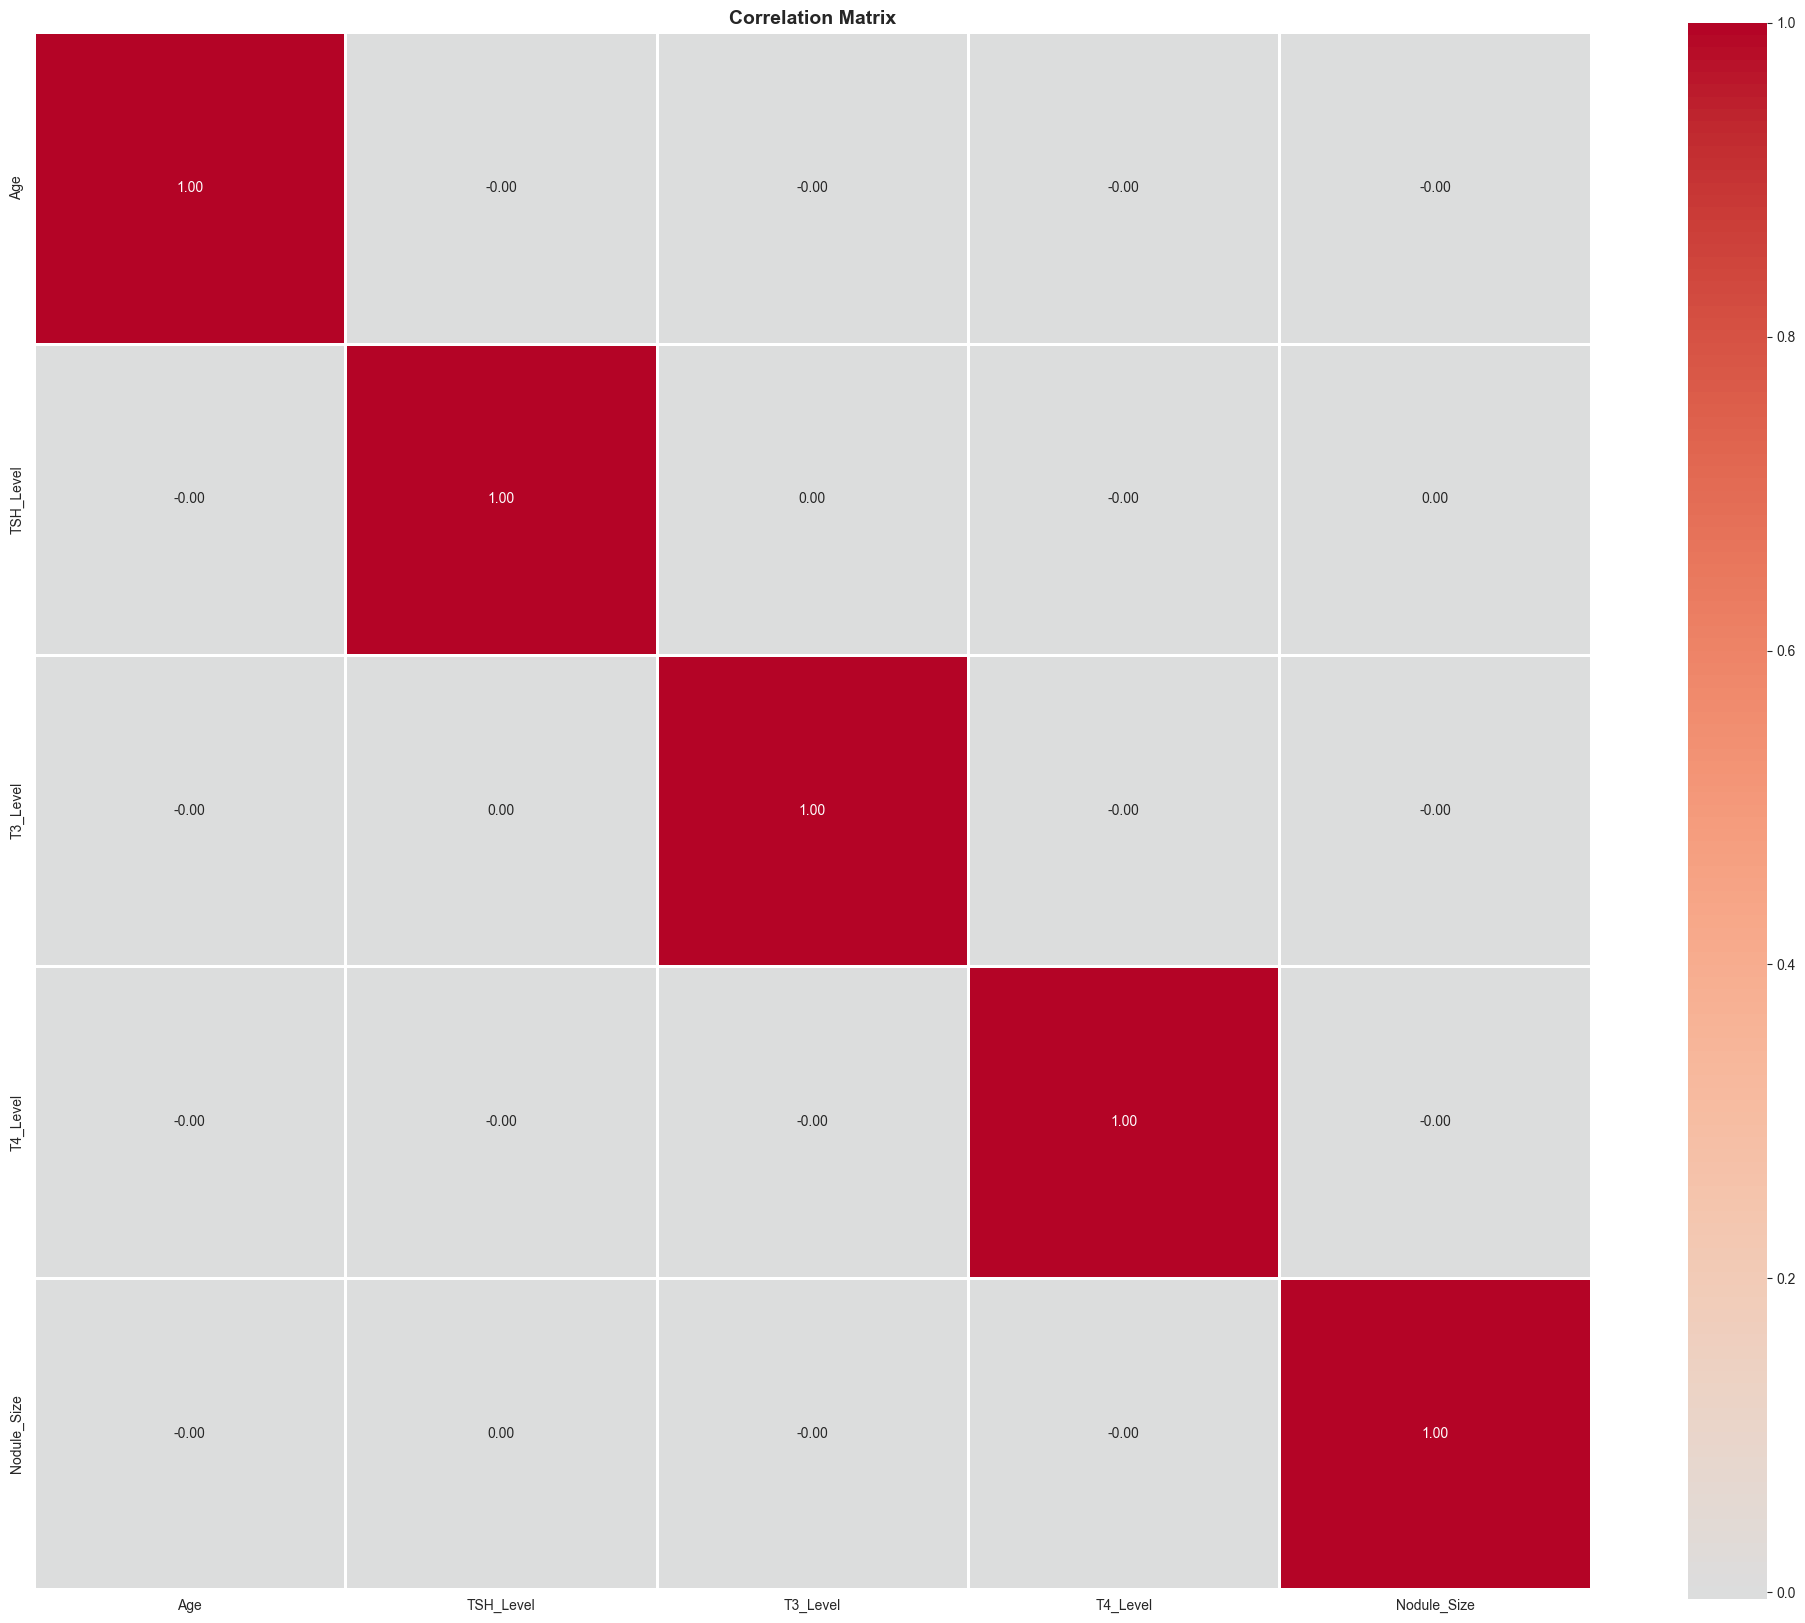

In [15]:
# create correlation matrix 

# generate correlations 

correlation_matrix = numeric_df.corr()
print(correlation_matrix.shape)

# take a look at what the correlation matrix looks like 

plt.figure(figsize=(20, 20))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../output/correlations.png", dpi=300)
plt.show()

# save to correlations csv 
correlation_matrix.to_csv('../output/correlations.csv')